In [1]:
!pip install -q torch scikit-learn pandas numpy matplotlib seaborn

Device: cuda
EBAMTN — SINGLE-TASK LEARNING (STL) | Delhi
Rows -> Train:52584  Val:1416  Test:744

Training EBAMTN-STL-PM25 ...
  Ep  20  train=0.00087  val=0.00045
  Early stop @ ep 24
  PM2.5 -> MAE=10.465  RMSE=13.715  R2=0.8807

Training EBAMTN-STL-PM10 ...
  Ep  20  train=0.00167  val=0.00067
  Early stop @ ep 30
  PM10  -> MAE=20.268  RMSE=25.580  R2=0.8946


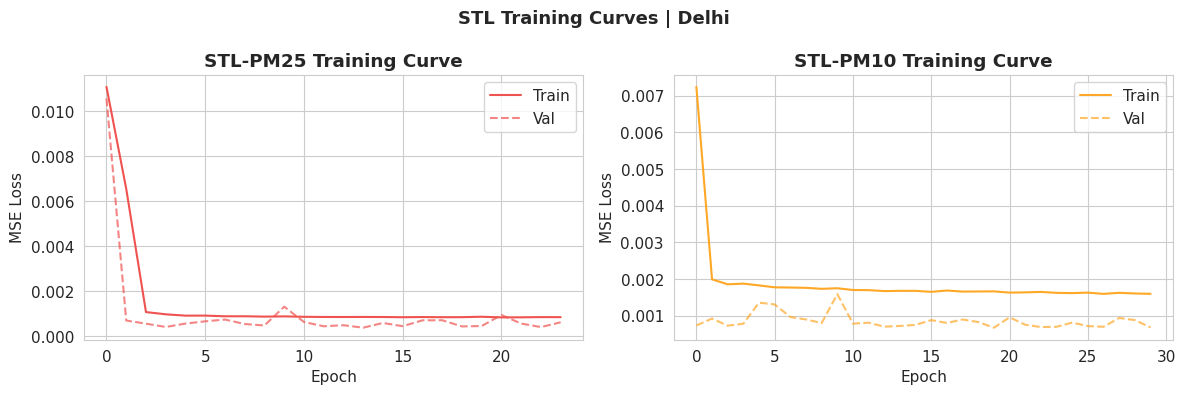

Saved: stl_training_curves.png


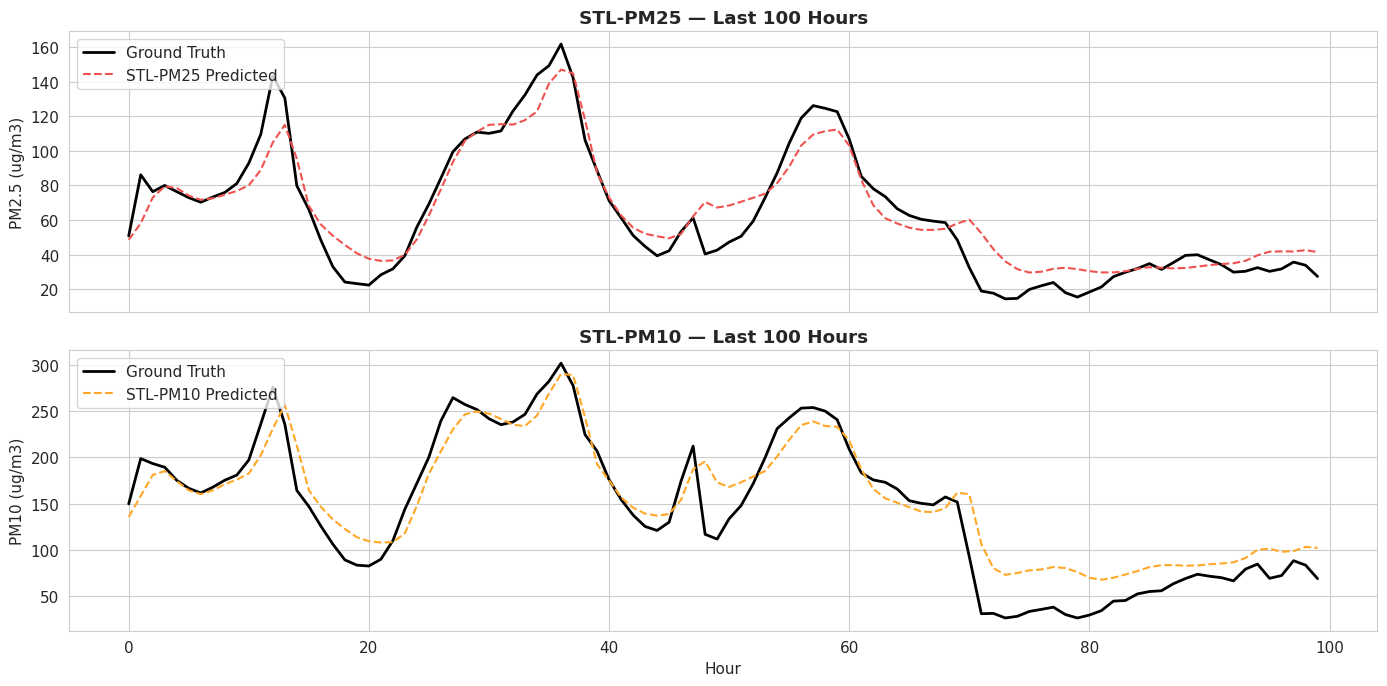

Saved: stl_timeseries.png

STL complete. stl_results, stl_preds, stl_loss_curves saved for comparison cell.


In [ ]:
import random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

CFG = dict(
    train_path = "Train_data.csv",        # <-- update if needed
    val_path = "Validation_data.csv",
    test_path = "Test_data.csv",
    feature_cols = ["pm25","pm10","no","nh3","no2","nox",
                     "so2","co","ozone","bp","wind_speed",
                     "air_temp","humidity","rainfall"],
    target_cols = ["pm25","pm10"],
    window_size = 168,
    batch_size = 128,
    lr = 1e-3,
    weight_decay = 1e-4,
    epochs = 100,
    patience = 10,
    noise_factor = 0.05,
    grad_clip = 1.0,
    tcn_channels = [32, 64, 128],
    bilstm_hidden = 64,
    bilstm_layers = 2,
    num_heads = 4,
    fusion_dim = 128,
    dropout = 0.1,
)

def _sort(df):
    col = "from_date" if "from_date" in df.columns else "Date"
    df[col] = pd.to_datetime(df[col])
    return df.sort_values(col).reset_index(drop=True)

def load_splits(cfg):
    cols = cfg["feature_cols"]
    dfs  = [_sort(pd.read_csv(p))[cols].dropna().reset_index(drop=True)
            for p in (cfg["train_path"], cfg["val_path"], cfg["test_path"])]
    scalers = {}
    scaled = [np.zeros((len(df), len(cols)), dtype=np.float32) for df in dfs]
    for i, col in enumerate(cols):
        sc = MinMaxScaler()
        scaled[0][:,i] = sc.fit_transform(dfs[0][[col]]).flatten()
        scaled[1][:,i] = sc.transform(dfs[1][[col]]).flatten()
        scaled[2][:,i] = sc.transform(dfs[2][[col]]).flatten()
        scalers[col] = sc
    print(f"Rows -> Train:{len(scaled[0])}  Val:{len(scaled[1])}  Test:{len(scaled[2])}")
    return scaled[0], scaled[1], scaled[2], scalers, cols

def make_sequences(data, window, tgt_idx):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i]); y.append(data[i, tgt_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

class AQDataset(Dataset):
    def __init__(self, X, y, noise=0.0):
        self.X=torch.tensor(X); self.y=torch.tensor(y); self.noise=noise
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        x = self.X[idx]
        if self.noise > 0: x = x + self.noise*torch.randn_like(x)
        return x, self.y[idx]

def make_loaders(X_tr,y_tr,X_va,y_va,X_te,y_te,cfg):
    kw = dict(batch_size=cfg["batch_size"], num_workers=2, pin_memory=True)
    return (DataLoader(AQDataset(X_tr,y_tr,cfg["noise_factor"]),shuffle=True, **kw),
            DataLoader(AQDataset(X_va,y_va), shuffle=False,**kw),
            DataLoader(AQDataset(X_te,y_te), shuffle=False,**kw))

class MultiScaleTCN(nn.Module):
    def __init__(self, in_ch, branch_ch=(32,64,128), dropout=0.1):
        super().__init__()
        branch_ch = list(branch_ch)
        self.branches = nn.ModuleList([
            nn.Sequential(nn.Conv1d(in_ch,oc,k,padding=k//2),
                          nn.BatchNorm1d(oc),nn.ReLU(),nn.Dropout(dropout))
            for k,oc in zip([3,5,7],branch_ch)])
        self.total_ch = sum(branch_ch)
        self.score_fcs = nn.ModuleList([nn.Linear(oc,1) for oc in branch_ch])
        self.proj_convs = nn.ModuleList([nn.Conv1d(oc,self.total_ch,1) for oc in branch_ch])
        ch = self.total_ch
        self.dil_layers = nn.ModuleList([
            nn.Sequential(nn.Conv1d(ch,ch,3,padding=2**l,dilation=2**l),
                          nn.BatchNorm1d(ch),nn.ReLU(),nn.Dropout(dropout))
            for l in range(4)])
        self.skip_convs = nn.ModuleList([nn.Conv1d(ch,ch,1) for _ in range(4)])

    def forward(self, x):
        x = x.permute(0,2,1)
        bouts = [b(x) for b in self.branches]
        scores = torch.cat([fc(bo.mean(-1)) for fc,bo in zip(self.score_fcs,bouts)],dim=-1)
        weights = torch.softmax(scores,dim=-1)
        projs = [pc(bo) for pc,bo in zip(self.proj_convs,bouts)]
        fused = sum(weights[:,i:i+1].unsqueeze(-1)*projs[i] for i in range(len(self.branches)))
        h,skip_sum = fused,0
        for dl,sk in zip(self.dil_layers,self.skip_convs):
            h=dl(h)+h; skip_sum=skip_sum+sk(h)
        return skip_sum.permute(0,2,1)

class BiLSTMAttention(nn.Module):
    def __init__(self, in_dim, hidden=64, layers=2, heads=4, dropout=0.1):
        super().__init__()
        self.bilstm = nn.LSTM(in_dim,hidden,layers,batch_first=True,
                              bidirectional=True,dropout=dropout if layers>1 else 0)
        self.attn = nn.MultiheadAttention(hidden*2,heads,dropout=dropout,batch_first=True)
        self.gate = nn.Linear(hidden*4,hidden*2)
        self.proj = nn.Linear(hidden*2,hidden*2)
    def forward(self, x):
        H,_ = self.bilstm(x); A,_ = self.attn(H,H,H)
        G = torch.sigmoid(self.gate(torch.cat([H,A],dim=-1)))
        return self.proj(G*H+(1-G)*A)

class GatedFusion(nn.Module):
    def __init__(self, tcn_dim, lstm_dim, fusion_dim, dropout=0.1):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(tcn_dim+lstm_dim,fusion_dim),
                                 nn.ReLU(),nn.Dropout(dropout))
        self.tam = nn.Linear(fusion_dim,1)
    def forward(self, f_tcn, f_lstm):
        h = self.fc(torch.cat([f_tcn,f_lstm],dim=-1))
        w = torch.sigmoid(self.tam(h))
        return (h*w)[:,-1,:]

class TaskHead(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim,hidden),nn.ReLU(),nn.Linear(hidden,1))
    def forward(self, x): return self.net(x).squeeze(-1)

class EBAMTN_STL(nn.Module):
    def __init__(self, n_feat, cfg):
        super().__init__()
        self.tcn = MultiScaleTCN(n_feat, cfg["tcn_channels"], cfg["dropout"])
        self.bilstm = BiLSTMAttention(n_feat, cfg["bilstm_hidden"],
                                      cfg["bilstm_layers"], cfg["num_heads"], cfg["dropout"])
        self.fusion = GatedFusion(sum(cfg["tcn_channels"]), cfg["bilstm_hidden"]*2,
                                  cfg["fusion_dim"], cfg["dropout"])
        self.head = TaskHead(cfg["fusion_dim"])
    def forward(self, x):
        return self.head(self.fusion(self.tcn(x), self.bilstm(x)))

def train_stl(model, tr_loader, va_loader, cfg, target_idx):
    opt = optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg["epochs"])
    mse = nn.MSELoss()
    best_val,best_w,wait = np.inf,None,0
    tr_hist,va_hist = [],[]
    for ep in range(1, cfg["epochs"]+1):
        model.train(); tl=0.0
        for xb,yb in tr_loader:
            xb,yb = xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad()
            loss = mse(model(xb), yb[:,target_idx])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            opt.step(); tl+=loss.item()*len(xb)
        sch.step(); tl/=len(tr_loader.dataset)
        model.eval(); vl=0.0
        with torch.no_grad():
            for xb,yb in va_loader:
                xb,yb=xb.to(DEVICE),yb.to(DEVICE)
                vl+=mse(model(xb),yb[:,target_idx]).item()*len(xb)
        vl/=len(va_loader.dataset)
        tr_hist.append(tl); va_hist.append(vl)
        if vl<best_val: best_val,best_w,wait=vl,deepcopy(model.state_dict()),0
        else:
            wait+=1
            if wait>=cfg["patience"]: print(f"  Early stop @ ep {ep}"); break
        if ep%20==0: print(f"  Ep {ep:3d}  train={tl:.5f}  val={vl:.5f}")
    model.load_state_dict(best_w)
    return model, tr_hist, va_hist

@torch.no_grad()
def predict_stl(model, loader, target_idx):
    model.eval(); preds,trues=[],[]
    for xb,yb in loader:
        preds.append(model(xb.to(DEVICE)).cpu().numpy())
        trues.append(yb[:,target_idx].numpy())
    return np.concatenate(preds), np.concatenate(trues)

def inv(arr,sc): return sc.inverse_transform(arr.reshape(-1,1)).flatten()
def get_metrics(true,pred):
    return dict(MAE=mean_absolute_error(true,pred),
                RMSE=np.sqrt(mean_squared_error(true,pred)),
                R2=r2_score(true,pred))

print("="*55)
print("EBAMTN — SINGLE-TASK LEARNING (STL) | Delhi")
print("="*55)

tr_d,va_d,te_d,scalers,feat_cols = load_splits(CFG)
tgt_idx = [feat_cols.index(c) for c in CFG["target_cols"]]
n_feat  = len(feat_cols)

X_tr,y_tr = make_sequences(tr_d, CFG["window_size"], tgt_idx)
X_va,y_va = make_sequences(va_d, CFG["window_size"], tgt_idx)
X_te,y_te = make_sequences(te_d, CFG["window_size"], tgt_idx)

tr_loader,va_loader,te_loader = make_loaders(X_tr,y_tr,X_va,y_va,X_te,y_te,CFG)

stl_results = {}
stl_loss_curves = {}
stl_preds = {}

print("\nTraining EBAMTN-STL-PM25 ...")
stl25 = EBAMTN_STL(n_feat, CFG).to(DEVICE)
stl25,tl,vl = train_stl(stl25, tr_loader, va_loader, CFG, target_idx=0)
p,t = predict_stl(stl25, te_loader, target_idx=0)
p_r,t_r = inv(p,scalers["pm25"]), inv(t,scalers["pm25"])
m = get_metrics(t_r, p_r)
stl_results["EBAMTN-STL-PM25"] = {"pm25": m, "pm10": None}
stl_loss_curves["EBAMTN-STL-PM25"] = {"train": tl, "val": vl}
stl_preds["EBAMTN-STL-PM25"] = {"p25": p_r, "t25": t_r}
print(f"  PM2.5 -> MAE={m['MAE']:.3f}  RMSE={m['RMSE']:.3f}  R2={m['R2']:.4f}")

print("\nTraining EBAMTN-STL-PM10 ...")
stl10 = EBAMTN_STL(n_feat, CFG).to(DEVICE)
stl10,tl,vl = train_stl(stl10, tr_loader, va_loader, CFG, target_idx=1)
p,t = predict_stl(stl10, te_loader, target_idx=1)
p_r,t_r = inv(p,scalers["pm10"]), inv(t,scalers["pm10"])
m = get_metrics(t_r, p_r)
stl_results["EBAMTN-STL-PM10"] = {"pm25": None, "pm10": m}
stl_loss_curves["EBAMTN-STL-PM10"] = {"train": tl, "val": vl}
stl_preds["EBAMTN-STL-PM10"] = {"p10": p_r, "t10": t_r}
print(f"  PM10  -> MAE={m['MAE']:.3f}  RMSE={m['RMSE']:.3f}  R2={m['R2']:.4f}")

sns.set_style("whitegrid"); plt.rcParams.update({"font.size":11})
C = {"STL25":"#EF5350","STL10":"#FFA726","MTL":"#1E88E5"}

fig,axes = plt.subplots(1,2,figsize=(12,4))
for ax,(name,curves),col in zip(axes,stl_loss_curves.items(),[C["STL25"],C["STL10"]]):
    ax.plot(curves["train"],label="Train",color=col)
    ax.plot(curves["val"], label="Val", color=col,ls="--",alpha=0.7)
    ax.set_title(name.replace("EBAMTN-","")+" Training Curve",fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss"); ax.legend()
plt.suptitle("STL Training Curves | Delhi",fontsize=13,fontweight="bold")
plt.tight_layout(); plt.savefig("stl_training_curves.png",dpi=150,bbox_inches="tight")
plt.show(); print("Saved: stl_training_curves.png")

fig,axes = plt.subplots(2,1,figsize=(14,7),sharex=True)
N=100
axes[0].plot(stl_preds["EBAMTN-STL-PM25"]["t25"][-N:],color="black",lw=2,label="Ground Truth")
axes[0].plot(stl_preds["EBAMTN-STL-PM25"]["p25"][-N:],color=C["STL25"],lw=1.5,ls="--",label="STL-PM25 Predicted")
axes[0].set_ylabel("PM2.5 (ug/m3)"); axes[0].legend(loc="upper left")
axes[0].set_title("STL-PM25 — Last 100 Hours",fontweight="bold")
axes[1].plot(stl_preds["EBAMTN-STL-PM10"]["t10"][-N:],color="black",lw=2,label="Ground Truth")
axes[1].plot(stl_preds["EBAMTN-STL-PM10"]["p10"][-N:],color=C["STL10"],lw=1.5,ls="--",label="STL-PM10 Predicted")
axes[1].set_ylabel("PM10 (ug/m3)"); axes[1].set_xlabel("Hour"); axes[1].legend(loc="upper left")
axes[1].set_title("STL-PM10 — Last 100 Hours",fontweight="bold")
plt.tight_layout(); plt.savefig("stl_timeseries.png",dpi=150,bbox_inches="tight")
plt.show(); print("Saved: stl_timeseries.png")

print("\nSTL complete. stl_results, stl_preds, stl_loss_curves saved for comparison cell.")


EBAMTN — MULTI-TASK LEARNING (MTL) | Delhi

Training EBAMTN-MTL (PM2.5 + PM10 jointly) ...
  Early stop @ ep 15
  PM2.5 -> MAE=10.747  RMSE=13.644  R2=0.8820
  PM10  -> MAE=19.126  RMSE=24.530  R2=0.9030

Model                   PM2.5 MAE  PM2.5 RMSE  PM2.5 R2   PM10 MAE  PM10 RMSE  PM10 R2
------------------------------------------------------------------------
EBAMTN-STL-PM25            10.465      13.715    0.8807        ---        ---      ---
EBAMTN-STL-PM10               ---         ---       ---     20.268     25.580   0.8946
EBAMTN-MTL                 10.747      13.644    0.8820     19.126     24.530   0.9030


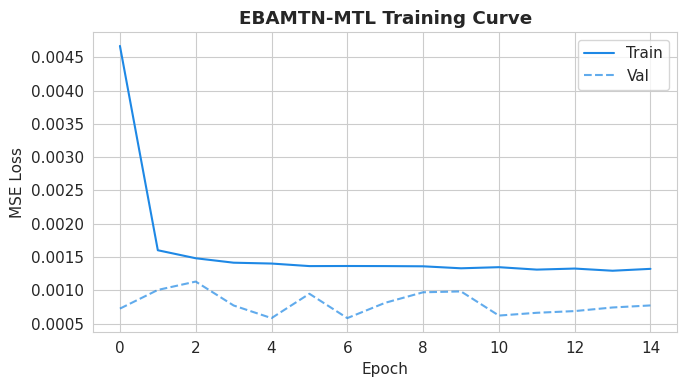

Saved: mtl_training_curve.png


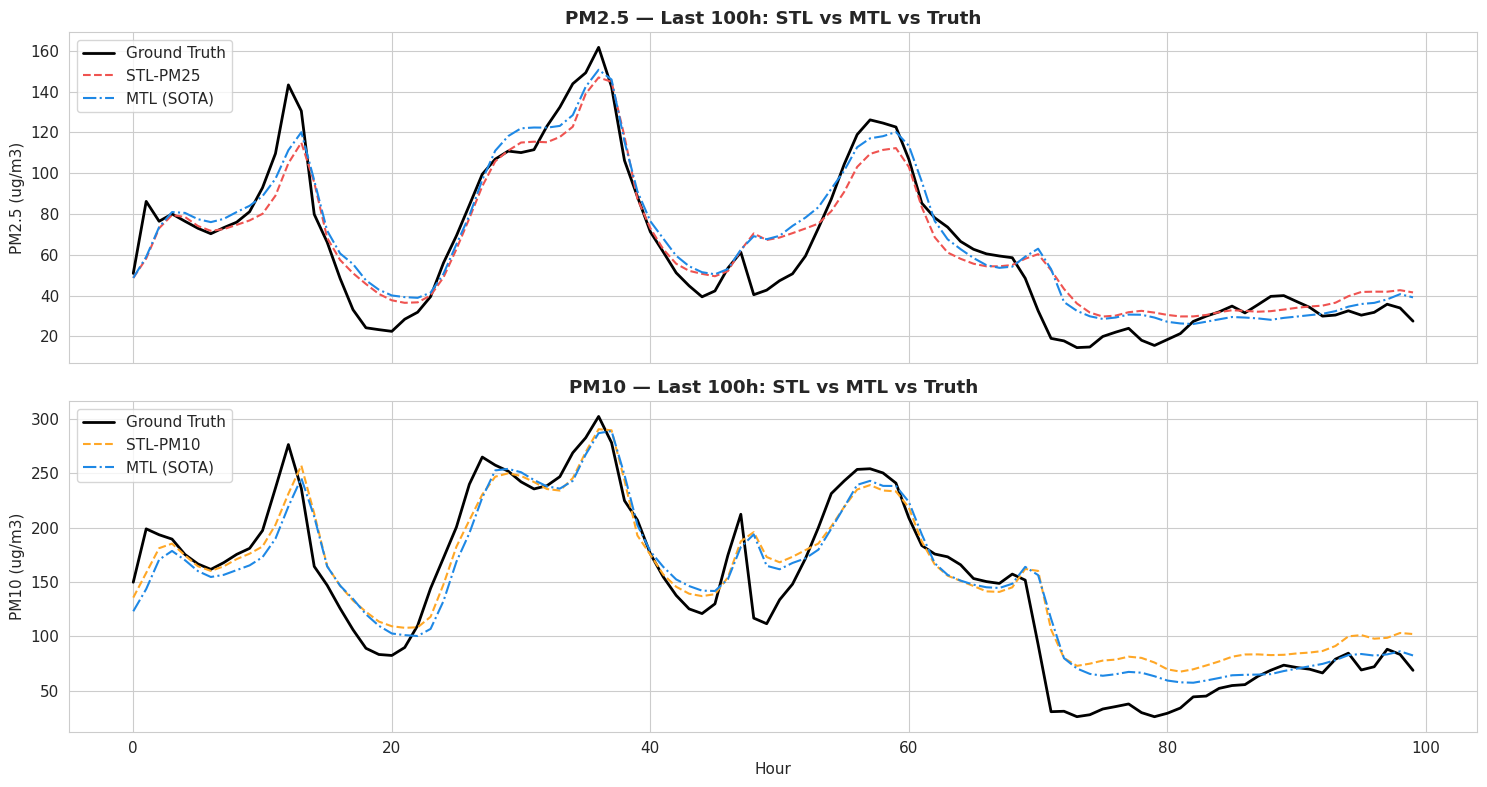

Saved: mtl_vs_stl_timeseries.png


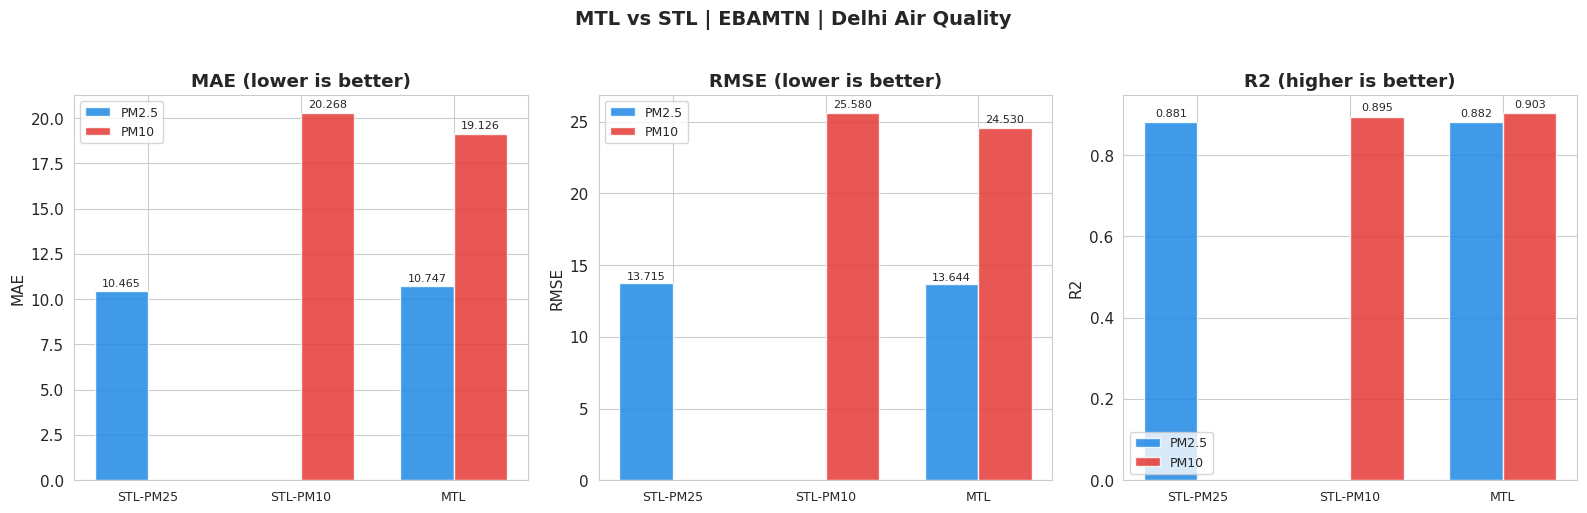

Saved: mtl_vs_stl_metrics.png


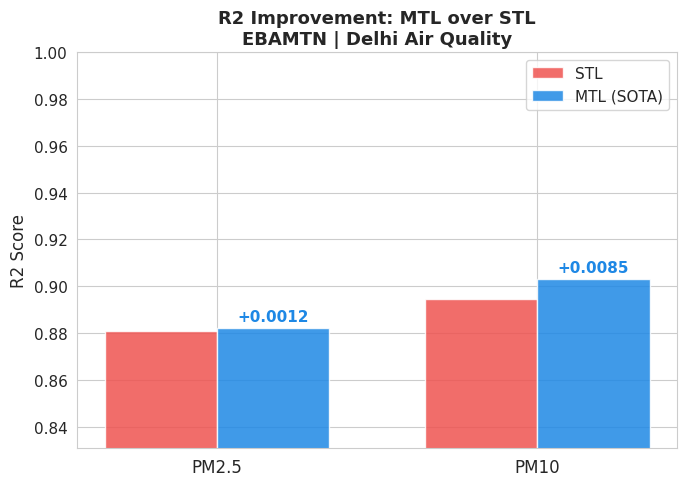

Saved: r2_improvement.png


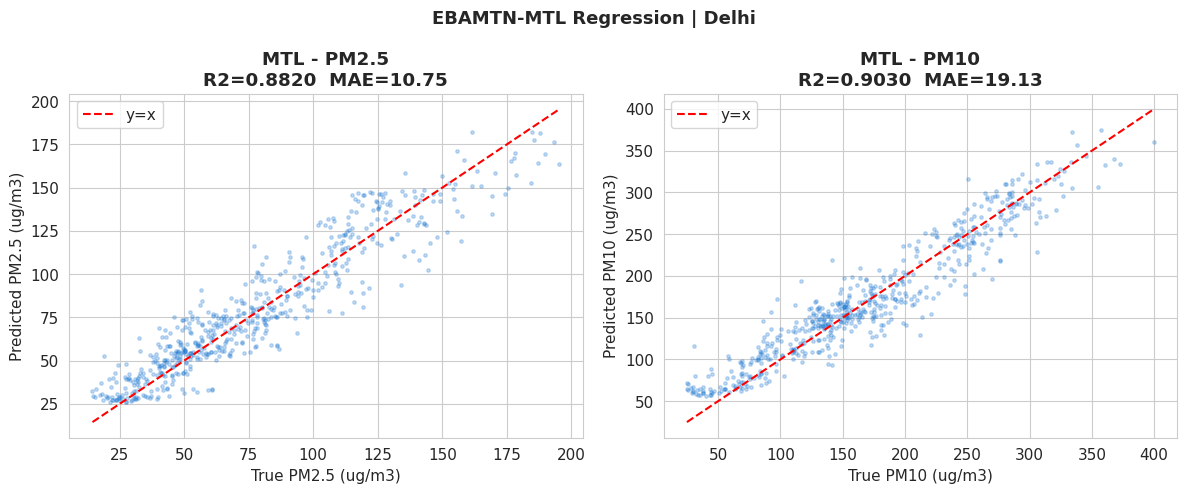

Saved: mtl_scatter.png

Done! MTL vs STL comparison complete.


In [ ]:
class EBAMTN_MTL(nn.Module):
    def __init__(self, n_feat, cfg):
        super().__init__()
        self.tcn = MultiScaleTCN(n_feat, cfg["tcn_channels"], cfg["dropout"])
        self.bilstm = BiLSTMAttention(n_feat, cfg["bilstm_hidden"],
                                         cfg["bilstm_layers"], cfg["num_heads"], cfg["dropout"])
        self.fusion = GatedFusion(sum(cfg["tcn_channels"]), cfg["bilstm_hidden"]*2,
                                     cfg["fusion_dim"], cfg["dropout"])
        self.head_pm25 = TaskHead(cfg["fusion_dim"])
        self.head_pm10 = TaskHead(cfg["fusion_dim"])

    def forward(self, x):
        fused = self.fusion(self.tcn(x), self.bilstm(x))
        return self.head_pm25(fused), self.head_pm10(fused)

def train_mtl(model, tr_loader, va_loader, cfg):
    opt = optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg["epochs"])
    mse = nn.MSELoss()
    best_val,best_w,wait = np.inf,None,0
    tr_hist,va_hist = [],[]
    for ep in range(1, cfg["epochs"]+1):
        model.train(); tl=0.0
        for xb,yb in tr_loader:
            xb,yb = xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad()
            p25,p10 = model(xb)
            loss = cfg["alpha"]*mse(p25,yb[:,0]) + (1-cfg["alpha"])*mse(p10,yb[:,1])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            opt.step(); tl+=loss.item()*len(xb)
        sch.step(); tl/=len(tr_loader.dataset)
        model.eval(); vl=0.0
        with torch.no_grad():
            for xb,yb in va_loader:
                xb,yb=xb.to(DEVICE),yb.to(DEVICE)
                p25,p10=model(xb)
                vl+=(cfg["alpha"]*mse(p25,yb[:,0])+(1-cfg["alpha"])*mse(p10,yb[:,1])).item()*len(xb)
        vl/=len(va_loader.dataset)
        tr_hist.append(tl); va_hist.append(vl)
        if vl<best_val: best_val,best_w,wait=vl,deepcopy(model.state_dict()),0
        else:
            wait+=1
            if wait>=cfg["patience"]: print(f"  Early stop @ ep {ep}"); break
        if ep%20==0: print(f"  Ep {ep:3d}  train={tl:.5f}  val={vl:.5f}")
    model.load_state_dict(best_w)
    return model, tr_hist, va_hist

@torch.no_grad()
def predict_mtl(model, loader):
    model.eval(); p25,p10,t25,t10=[],[],[],[]
    for xb,yb in loader:
        a,b=model(xb.to(DEVICE))
        p25.append(a.cpu().numpy()); p10.append(b.cpu().numpy())
        t25.append(yb[:,0].numpy()); t10.append(yb[:,1].numpy())
    return (np.concatenate(p25),np.concatenate(p10),
            np.concatenate(t25),np.concatenate(t10))

print("="*55)
print("EBAMTN — MULTI-TASK LEARNING (MTL) | Delhi")
print("="*55)

CFG["alpha"] = 0.5

print("\nTraining EBAMTN-MTL (PM2.5 + PM10 jointly) ...")
mtl_model = EBAMTN_MTL(n_feat, CFG).to(DEVICE)
mtl_model, mtl_tl, mtl_vl = train_mtl(mtl_model, tr_loader, va_loader, CFG)

p25,p10,t25,t10 = predict_mtl(mtl_model, te_loader)
p25_r=inv(p25,scalers["pm25"]); t25_r=inv(t25,scalers["pm25"])
p10_r=inv(p10,scalers["pm10"]); t10_r=inv(t10,scalers["pm10"])
m25 = get_metrics(t25_r, p25_r)
m10 = get_metrics(t10_r, p10_r)

mtl_results = {"EBAMTN-MTL": {"pm25": m25, "pm10": m10}}
mtl_preds = {"EBAMTN-MTL": {"p25":p25_r,"p10":p10_r,"t25":t25_r,"t10":t10_r}}

print(f"  PM2.5 -> MAE={m25['MAE']:.3f}  RMSE={m25['RMSE']:.3f}  R2={m25['R2']:.4f}")
print(f"  PM10  -> MAE={m10['MAE']:.3f}  RMSE={m10['RMSE']:.3f}  R2={m10['R2']:.4f}")

all_results = {**stl_results, **mtl_results}
print("\n" + "="*72)
print(f"{'Model':<22} {'PM2.5 MAE':>10} {'PM2.5 RMSE':>11} {'PM2.5 R2':>9}"
      f"  {'PM10 MAE':>9} {'PM10 RMSE':>10} {'PM10 R2':>8}")
print("-"*72)
for name,res in all_results.items():
    m25r=res["pm25"]; m10r=res["pm10"]
    s25=(f"{m25r['MAE']:>10.3f} {m25r['RMSE']:>11.3f} {m25r['R2']:>9.4f}"
         if m25r else f"{'---':>10} {'---':>11} {'---':>9}")
    s10=(f"{m10r['MAE']:>9.3f} {m10r['RMSE']:>10.3f} {m10r['R2']:>8.4f}"
         if m10r else f"{'---':>9} {'---':>10} {'---':>8}")
    print(f"{name:<22} {s25}  {s10}")
print("="*72)

C = {"STL25":"#EF5350","STL10":"#FFA726","MTL":"#1E88E5"}
N = 100

fig,ax = plt.subplots(figsize=(7,4))
ax.plot(mtl_tl,label="Train",color=C["MTL"])
ax.plot(mtl_vl,label="Val",  color=C["MTL"],ls="--",alpha=0.7)
ax.set_title("EBAMTN-MTL Training Curve",fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss"); ax.legend()
plt.tight_layout(); plt.savefig("mtl_training_curve.png",dpi=150,bbox_inches="tight")
plt.show(); print("Saved: mtl_training_curve.png")

fig,axes=plt.subplots(2,1,figsize=(15,8),sharex=True)
ax=axes[0]
ax.plot(t25_r[-N:],color="black",lw=2,label="Ground Truth")
ax.plot(stl_preds["EBAMTN-STL-PM25"]["p25"][-N:],color=C["STL25"],lw=1.5,ls="--",label="STL-PM25")
ax.plot(p25_r[-N:],color=C["MTL"],lw=1.5,ls="-.",label="MTL (SOTA)")
ax.set_ylabel("PM2.5 (ug/m3)"); ax.legend(loc="upper left")
ax.set_title("PM2.5 — Last 100h: STL vs MTL vs Truth",fontweight="bold")
ax=axes[1]
ax.plot(t10_r[-N:],color="black",lw=2,label="Ground Truth")
ax.plot(stl_preds["EBAMTN-STL-PM10"]["p10"][-N:],color=C["STL10"],lw=1.5,ls="--",label="STL-PM10")
ax.plot(p10_r[-N:],color=C["MTL"],lw=1.5,ls="-.",label="MTL (SOTA)")
ax.set_ylabel("PM10 (ug/m3)"); ax.set_xlabel("Hour"); ax.legend(loc="upper left")
ax.set_title("PM10 — Last 100h: STL vs MTL vs Truth",fontweight="bold")
plt.tight_layout(); plt.savefig("mtl_vs_stl_timeseries.png",dpi=150,bbox_inches="tight")
plt.show(); print("Saved: mtl_vs_stl_timeseries.png")


fig,axes=plt.subplots(1,3,figsize=(16,5))
keys=list(all_results.keys()); x,w=np.arange(len(keys)),0.35
for ax,metric,better in zip(axes,["MAE","RMSE","R2"],["lower","lower","higher"]):
    v25=[all_results[k]["pm25"][metric] if all_results[k]["pm25"] else np.nan for k in keys]
    v10=[all_results[k]["pm10"][metric] if all_results[k]["pm10"] else np.nan for k in keys]
    b1=ax.bar(x-w/2,v25,w,label="PM2.5",color="#1E88E5",alpha=0.85)
    b2=ax.bar(x+w/2,v10,w,label="PM10", color="#E53935",alpha=0.85)
    for b in list(b1)+list(b2):
        v=b.get_height()
        if not np.isnan(v):
            ax.text(b.get_x()+b.get_width()/2,v*1.01,f"{v:.3f}",
                    ha="center",va="bottom",fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels([k.replace("EBAMTN-","") for k in keys],fontsize=9)
    ax.set_title(f"{metric} ({better} is better)",fontweight="bold")
    ax.set_ylabel(metric); ax.legend(fontsize=9)
plt.suptitle("MTL vs STL | EBAMTN | Delhi Air Quality",fontsize=14,fontweight="bold",y=1.02)
plt.tight_layout(); plt.savefig("mtl_vs_stl_metrics.png",dpi=150,bbox_inches="tight")
plt.show(); print("Saved: mtl_vs_stl_metrics.png")


fig,ax=plt.subplots(figsize=(7,5))
stl25_r2=stl_results["EBAMTN-STL-PM25"]["pm25"]["R2"]
stl10_r2=stl_results["EBAMTN-STL-PM10"]["pm10"]["R2"]
mtl25_r2=mtl_results["EBAMTN-MTL"]["pm25"]["R2"]
mtl10_r2=mtl_results["EBAMTN-MTL"]["pm10"]["R2"]
x,w=np.arange(2),0.35
ax.bar(x-w/2,[stl25_r2,stl10_r2],w,label="STL",color="#EF5350",alpha=0.85)
ax.bar(x+w/2,[mtl25_r2,mtl10_r2],w,label="MTL (SOTA)",color=C["MTL"],alpha=0.85)
for i,(s,m) in enumerate(zip([stl25_r2,stl10_r2],[mtl25_r2,mtl10_r2])):
    gain=m-s
    ax.annotate(f"{'+' if gain>=0 else ''}{gain:.4f}",
                xy=(i+w/2,m+0.003),ha="center",fontsize=11,color=C["MTL"],fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(["PM2.5","PM10"],fontsize=12)
ax.set_ylabel("R2 Score",fontsize=12)
ax.set_ylim(max(0,min(stl25_r2,stl10_r2,mtl25_r2,mtl10_r2)-0.05),1.0)
ax.set_title("R2 Improvement: MTL over STL\nEBAMTN | Delhi Air Quality",
             fontweight="bold",fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout(); plt.savefig("r2_improvement.png",dpi=150,bbox_inches="tight")
plt.show(); print("Saved: r2_improvement.png")


fig,axes=plt.subplots(1,2,figsize=(12,5))
for ax,true,pred,label in [
    (axes[0],t25_r,p25_r,"PM2.5"),
    (axes[1],t10_r,p10_r,"PM10")]:
    ax.scatter(true,pred,alpha=0.25,s=6,color="#1976D2")
    lo=min(true.min(),pred.min()); hi=max(true.max(),pred.max())
    ax.plot([lo,hi],[lo,hi],"r--",lw=1.5,label="y=x")
    m=get_metrics(true,pred)
    ax.set_title(f"MTL - {label}\nR2={m['R2']:.4f}  MAE={m['MAE']:.2f}",fontweight="bold")
    ax.set_xlabel(f"True {label} (ug/m3)"); ax.set_ylabel(f"Predicted {label} (ug/m3)")
    ax.legend()
plt.suptitle("EBAMTN-MTL Regression | Delhi",fontsize=13,fontweight="bold")
plt.tight_layout(); plt.savefig("mtl_scatter.png",dpi=150,bbox_inches="tight")
plt.show(); print("Saved: mtl_scatter.png")

print("\nDone! MTL vs STL comparison complete.")
